### Exercise 5: Implement the PCA Class

### 5.1) Add the "PCA" class

In [9]:
import numpy as np

class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None
        self.components = None
        self.explained_variance = None

    def _fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        covariance_matrix = np.cov(X_centered, rowvar=False)

        eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

        sorted_indices = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_indices]
        eigenvectors = eigenvectors[:, sorted_indices]

        self.components = eigenvectors[:, :self.n_components]
        self.explained_variance = eigenvalues[:self.n_components] / np.sum(eigenvalues)

    def _transform(self, X):
        X_centered = X - self.mean

        return np.dot(X_centered, self.components)

 ### 5.2) Test the PCA class

Mean of the samples:
 [5.84333333 3.05733333 3.758      1.19933333]
Principal Components:
 [[ 0.36138659 -0.65658877]
 [-0.08452251 -0.73016143]
 [ 0.85667061  0.17337266]
 [ 0.3582892   0.07548102]]
Explained Variance:
 [0.92461872 0.05306648]
Reduced Dataset (first 5 rows):
 [[-2.68412563 -0.31939725]
 [-2.71414169  0.17700123]
 [-2.88899057  0.14494943]
 [-2.74534286  0.31829898]
 [-2.72871654 -0.32675451]]


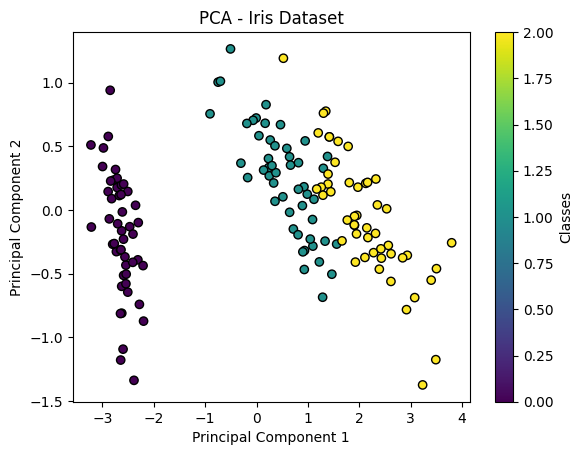

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None
        self.components = None
        self.explained_variance = None

    def _fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        covariance_matrix = np.cov(X_centered, rowvar=False)

        eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

        sorted_indices = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_indices]
        eigenvectors = eigenvectors[:, sorted_indices]

        self.components = eigenvectors[:, :self.n_components]
        self.explained_variance = eigenvalues[:self.n_components] / np.sum(eigenvalues)

    def _transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

iris = load_iris()
X = iris.data  
y = iris.target  

pca = PCA(n_components=2)  
pca._fit(X)

X_reduced = pca._transform(X)

print("Mean of the samples:\n", pca.mean)
print("Principal Components:\n", pca.components)
print("Explained Variance:\n", pca.explained_variance)
print("Reduced Dataset (first 5 rows):\n", X_reduced[:5])

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap="viridis", edgecolor='k')
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("PCA - Iris Dataset")
plt.colorbar(label='Classes')
plt.show()
